# Algorytm K-Najbliższych Sąsiadów (KNN)

## Zadanie 1 – Klasyfikacja toksyczności jezior (Toxins5.csv)
## Zadanie 2 – Klasyfikacja zasolenia jezior (JezPrzymClass.csv)

## Import pakietów, funkcji i klas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pandas.plotting import parallel_coordinates, andrews_curves

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

---
# Zadanie 1 – Klasyfikacja toksyczności jezior

Przewidywanie klasy jakości jeziora (low / middle / high) na podstawie cech toksyczności:
- **TN** – azot ogólny
- **Chlorophyla** – chlorofil a
- **TDI** – indeks okrzemkowy
- **TTC** – stężenie toksyn

## 1.1 Wczytanie i eksploracja danych (Toxins5)

In [2]:
df_tox = pd.read_csv("data/Toxins5.csv")
df_tox.columns = df_tox.columns.str.strip()

display(df_tox.head(10))
print("Wymiary zbioru:", df_tox.shape)
print("\nStatystyki opisowe:")
display(df_tox.describe())
print("\nRozkład klas Toxicity:")
print(df_tox["Toxicity"].value_counts())

,TN,Chlorophyla,TDI,TTC,Toxicity
0,0.57,0.62,0.42,0.00,low
1,0.18,5.91,1.05,0.01,low
2,0.21,5.33,0.39,0.02,low
3,1.07,6.71,1.00,0.67,middle
4,0.36,2.59,1.07,0.18,middle
5,1.43,1.13,0.00,0.00,low
6,0.66,2.66,0.62,0.02,low
7,0.54,4.17,0.65,0.01,low
8,1.38,11.18,1.18,0.24,middle
9,0.60,7.60,0.86,1.55,high


Wymiary zbioru: (137, 5)

Statystyki opisowe:


,TN,Chlorophyla,TDI,TTC
count,137.000000,137.000000,137.000000,137.000000
mean,0.941022,39.032774,0.780657,1.351095
std,0.800613,72.623651,0.394969,2.849098
min,0.070000,0.480000,0.000000,0.000000
25%,0.410000,5.330000,0.530000,0.030000
50%,0.730000,16.440000,0.880000,0.190000
75%,1.160000,50.480000,1.060000,0.900000
max,4.570000,690.160000,1.440000,17.190000



Rozkład klas Toxicity:
Toxicity
low       57
middle    46
high      34
Name: count, dtype: int64


## 1.2 Wizualizacje danych (Toxins5)

### 1.2.1 Parallel Coordinates Plot

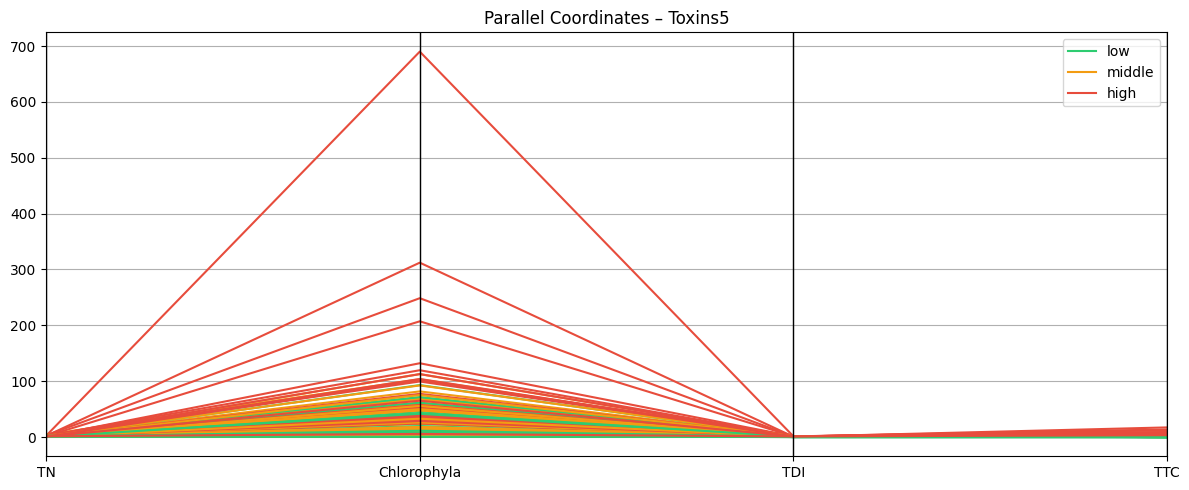

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
parallel_coordinates(df_tox, class_column="Toxicity", cols=["TN", "Chlorophyla", "TDI", "TTC"],
                     color=["#2ecc71", "#f39c12", "#e74c3c"], ax=ax)
ax.set_title("Parallel Coordinates – Toxins5")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 1.2.2 Andrews Curves

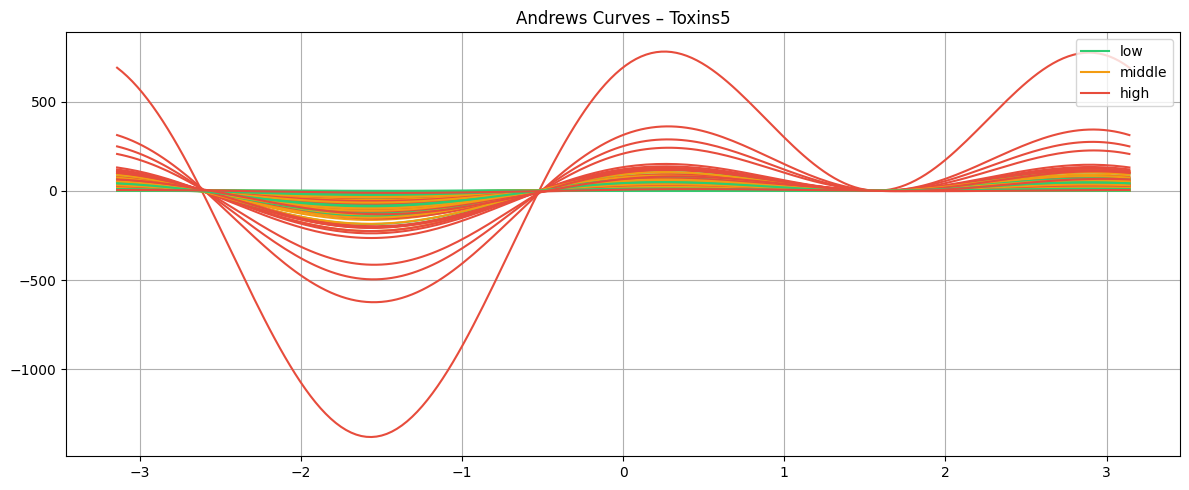

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
andrews_curves(df_tox, class_column="Toxicity",
               color=["#2ecc71", "#f39c12", "#e74c3c"], ax=ax)
ax.set_title("Andrews Curves – Toxins5")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 1.2.3 Pairplot

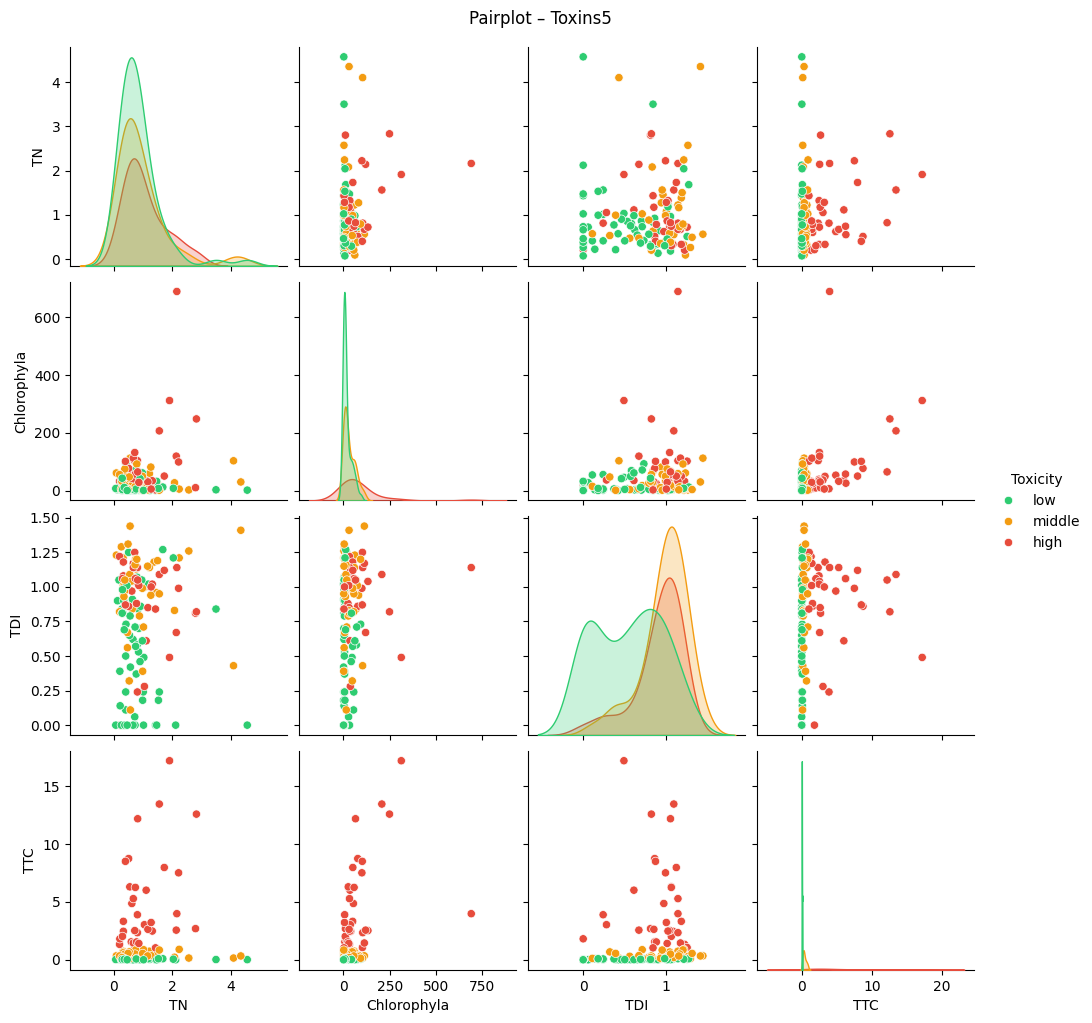

In [5]:
sns.pairplot(df_tox, hue="Toxicity",
             palette={"low": "#2ecc71", "middle": "#f39c12", "high": "#e74c3c"},
             diag_kind="kde")
plt.suptitle("Pairplot – Toxins5", y=1.02)
plt.show()

### 1.2.4 Box Plot

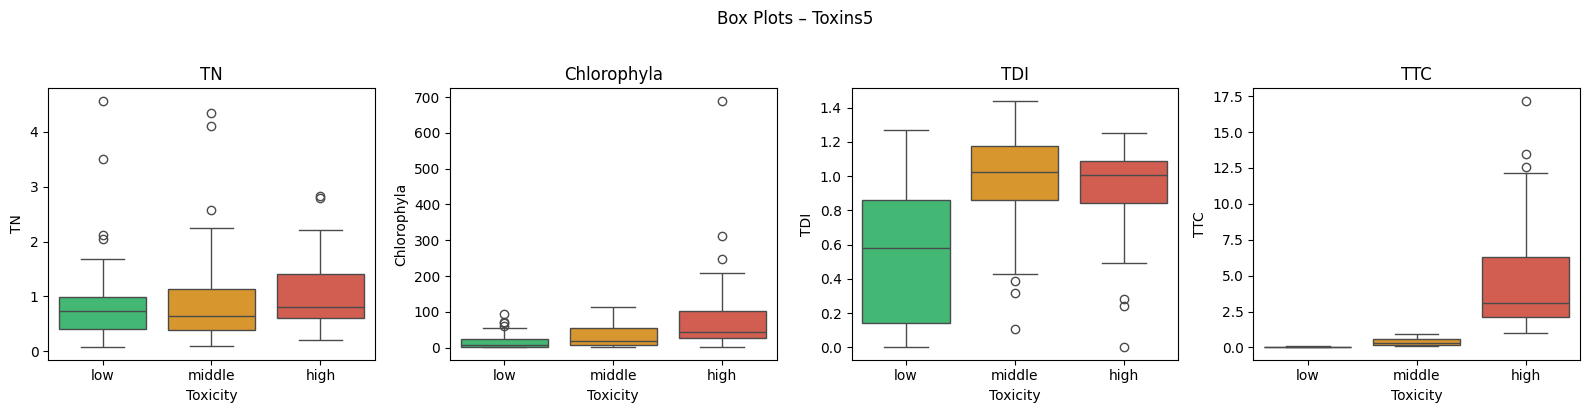

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(["TN", "Chlorophyla", "TDI", "TTC"]):
    sns.boxplot(x="Toxicity", y=col, hue="Toxicity", data=df_tox, ax=axes[i],
                order=["low", "middle", "high"],
                palette={"low": "#2ecc71", "middle": "#f39c12", "high": "#e74c3c"},
                legend=False)
    axes[i].set_title(col)
plt.suptitle("Box Plots – Toxins5", y=1.02)
plt.tight_layout()
plt.show()

### 1.2.5 Wizualizacja 3D (Chlorophyla, TN, TTC)

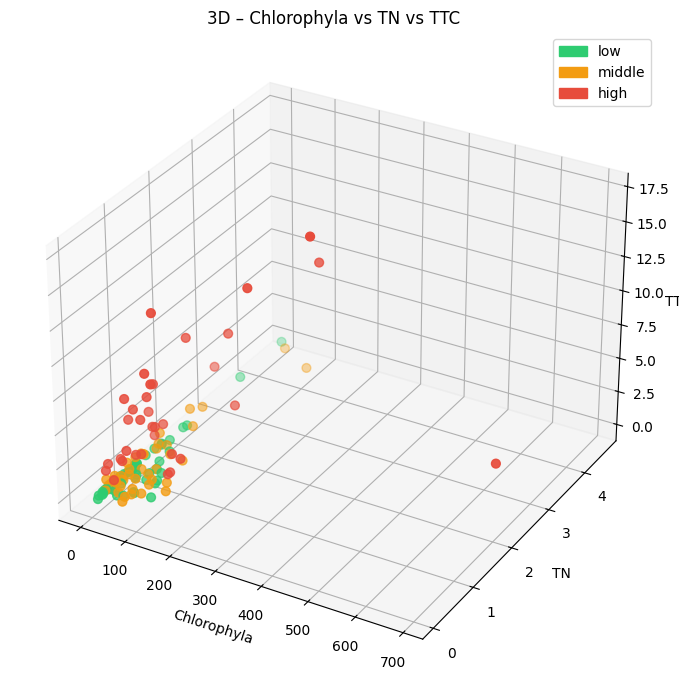

In [7]:
color_map = {"low": "#2ecc71", "middle": "#f39c12", "high": "#e74c3c"}
colors = df_tox["Toxicity"].map(color_map)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_tox["Chlorophyla"], df_tox["TN"], df_tox["TTC"], c=colors, s=40)
ax.set_xlabel("Chlorophyla")
ax.set_ylabel("TN")
ax.set_zlabel("TTC")
ax.set_title("3D – Chlorophyla vs TN vs TTC")

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

## 1.3 Budowa modelu KNN (Toxins5)

In [8]:
X_tox = df_tox[["TN", "Chlorophyla", "TDI", "TTC"]]
y_tox = df_tox["Toxicity"]

X_tox_train, X_tox_test, y_tox_train, y_tox_test = train_test_split(
    X_tox, y_tox, test_size=0.2, random_state=0
)

scaler_tox = StandardScaler()
X_tox_train_sc = scaler_tox.fit_transform(X_tox_train)
X_tox_test_sc = scaler_tox.transform(X_tox_test)

knn_tox = KNeighborsClassifier(n_neighbors=5)
knn_tox.fit(X_tox_train_sc, y_tox_train)

y_tox_pred = knn_tox.predict(X_tox_test_sc)

print("Accuracy (Toxins5):", metrics.accuracy_score(y_tox_test, y_tox_pred))
print("\nMacierz pomyłek:")
print(metrics.confusion_matrix(y_tox_test, y_tox_pred))
print("\nRaport klasyfikacji:")
print(metrics.classification_report(y_tox_test, y_tox_pred))

Accuracy (Toxins5): 0.75

Macierz pomyłek:
[[ 3  1  2]
 [ 0 10  2]
 [ 0  2  8]]

Raport klasyfikacji:
              precision    recall  f1-score   support

        high       1.00      0.50      0.67         6
         low       0.77      0.83      0.80        12
      middle       0.67      0.80      0.73        10

    accuracy                           0.75        28
   macro avg       0.81      0.71      0.73        28
weighted avg       0.78      0.75      0.75        28



### 1.3.1 Wykres błędu klasyfikacji vs liczba sąsiadów K

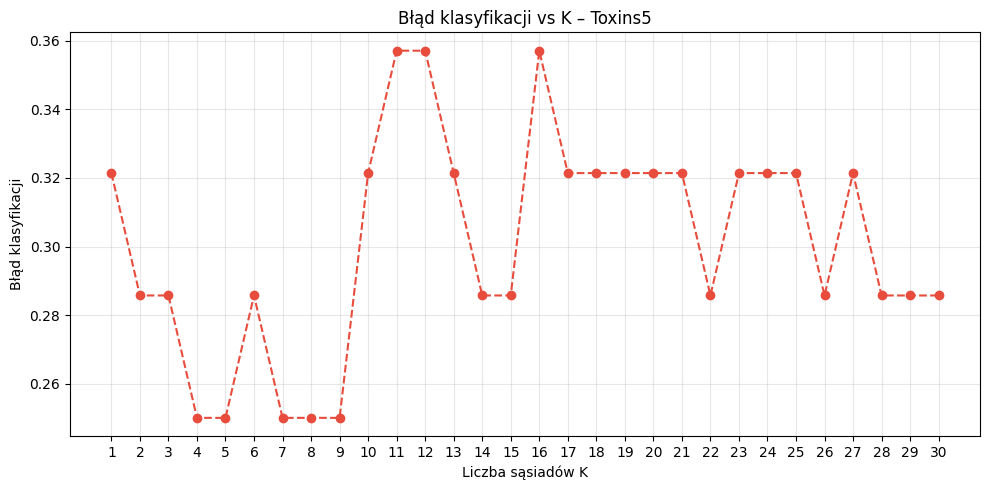

Najlepsze K = 4, błąd = 0.2500


In [9]:
error_rate_tox = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_tox_train_sc, y_tox_train)
    y_temp = knn_temp.predict(X_tox_test_sc)
    error_rate_tox.append(1 - metrics.accuracy_score(y_tox_test, y_temp))

plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rate_tox, marker="o", linestyle="--", color="#e74c3c")
plt.xlabel("Liczba sąsiadów K")
plt.ylabel("Błąd klasyfikacji")
plt.title("Błąd klasyfikacji vs K – Toxins5")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_tox = k_range[np.argmin(error_rate_tox)]
print(f"Najlepsze K = {best_k_tox}, błąd = {min(error_rate_tox):.4f}")

### 1.3.2 Model z optymalnym K (Toxins5)

In [10]:
knn_tox_best = KNeighborsClassifier(n_neighbors=best_k_tox)
knn_tox_best.fit(X_tox_train_sc, y_tox_train)
y_tox_pred_best = knn_tox_best.predict(X_tox_test_sc)

print(f"Accuracy z K={best_k_tox} (Toxins5):", metrics.accuracy_score(y_tox_test, y_tox_pred_best))
print("\nMacierz pomyłek:")
print(metrics.confusion_matrix(y_tox_test, y_tox_pred_best))
print("\nRaport klasyfikacji:")
print(metrics.classification_report(y_tox_test, y_tox_pred_best))

Accuracy z K=4 (Toxins5): 0.75

Macierz pomyłek:
[[ 5  1  0]
 [ 0 10  2]
 [ 0  4  6]]

Raport klasyfikacji:
              precision    recall  f1-score   support

        high       1.00      0.83      0.91         6
         low       0.67      0.83      0.74        12
      middle       0.75      0.60      0.67        10

    accuracy                           0.75        28
   macro avg       0.81      0.76      0.77        28
weighted avg       0.77      0.75      0.75        28



---
# Zadanie 2 – Klasyfikacja zasolenia jezior

Przewidywanie klasy zasolenia jeziora (Oligohaline / Mesohaline / Freshwater / Freshwater-isolated) na podstawie biomasy 4 gatunków zooplanktonu:
- **Keratella_cochlearis_tecta**
- **Polyarthra_vulgaris**
- **Pompholyx_sulcata**
- **Mesocyclops_leuckarti**

## 2.1 Wczytanie i eksploracja danych (JezPrzymClass)

In [11]:
df_jez = pd.read_csv("data/JezPrzymClass.csv")
df_jez.columns = df_jez.columns.str.strip()

feature_cols_jez = ["Keratella_cochlearis_tecta", "Polyarthra_vulgaris",
                    "Pompholyx_sulcata", "Mesocyclops_leuckarti"]

display(df_jez.head(10))
print("Wymiary zbioru:", df_jez.shape)
print("\nStatystyki opisowe:")
display(df_jez.describe())
print("\nRozkład klas Lake_class:")
print(df_jez["Lake_class"].value_counts())

,Id,Keratella_cochlearis_tecta,Polyarthra_vulgaris,Pompholyx_sulcata,Mesocyclops_leuckarti,Lake_class
0,1,0.03,0.0,0.0,0.00,Oligohaline
1,2,0.08,0.0,0.0,0.09,Oligohaline
2,3,0.06,0.0,0.0,0.08,Oligohaline
3,4,0.04,0.0,0.0,0.14,Oligohaline
4,5,0.02,0.0,0.0,0.00,Oligohaline
5,6,0.11,0.0,0.0,0.05,Mesohaline
6,7,0.16,0.0,0.0,0.00,Mesohaline
7,8,0.19,0.0,0.0,0.03,Mesohaline
8,9,0.24,0.0,0.0,0.05,Mesohaline
9,10,0.21,0.0,0.0,0.00,Mesohaline


Wymiary zbioru: (59, 6)

Statystyki opisowe:


,Id,Keratella_cochlearis_tecta,Polyarthra_vulgaris,Pompholyx_sulcata,Mesocyclops_leuckarti
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,30.000000,0.059831,0.000508,0.002203,0.066271
std,17.175564,0.069220,0.002216,0.007208,0.119624
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,15.500000,0.020000,0.000000,0.000000,0.000000
50%,30.000000,0.040000,0.000000,0.000000,0.000000
75%,44.500000,0.070000,0.000000,0.000000,0.090000
max,59.000000,0.320000,0.010000,0.030000,0.580000



Rozkład klas Lake_class:
Lake_class
Freshwater             29
Oligohaline            15
Mesohaline             10
Freshwater-isolated     5
Name: count, dtype: int64


## 2.2 Wizualizacje danych (JezPrzymClass)

### 2.2.1 Parallel Coordinates Plot

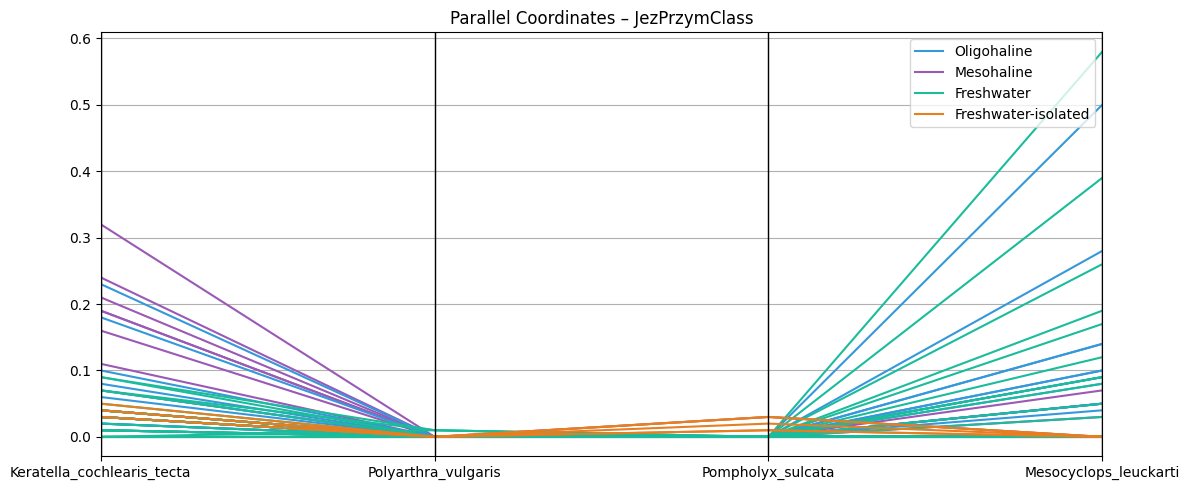

In [12]:
df_jez_vis = df_jez[feature_cols_jez + ["Lake_class"]].copy()
jez_palette = ["#3498db", "#9b59b6", "#1abc9c", "#e67e22"]

fig, ax = plt.subplots(figsize=(12, 5))
parallel_coordinates(df_jez_vis, class_column="Lake_class",
                     color=jez_palette, ax=ax)
ax.set_title("Parallel Coordinates – JezPrzymClass")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 2.2.2 Andrews Curves

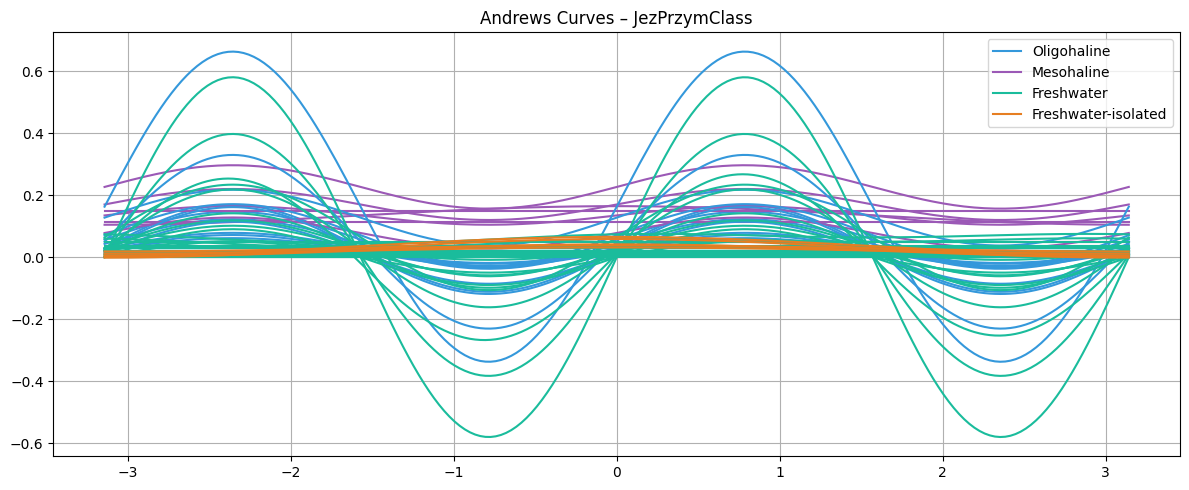

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
andrews_curves(df_jez_vis, class_column="Lake_class",
               color=jez_palette, ax=ax)
ax.set_title("Andrews Curves – JezPrzymClass")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 2.2.3 Pairplot

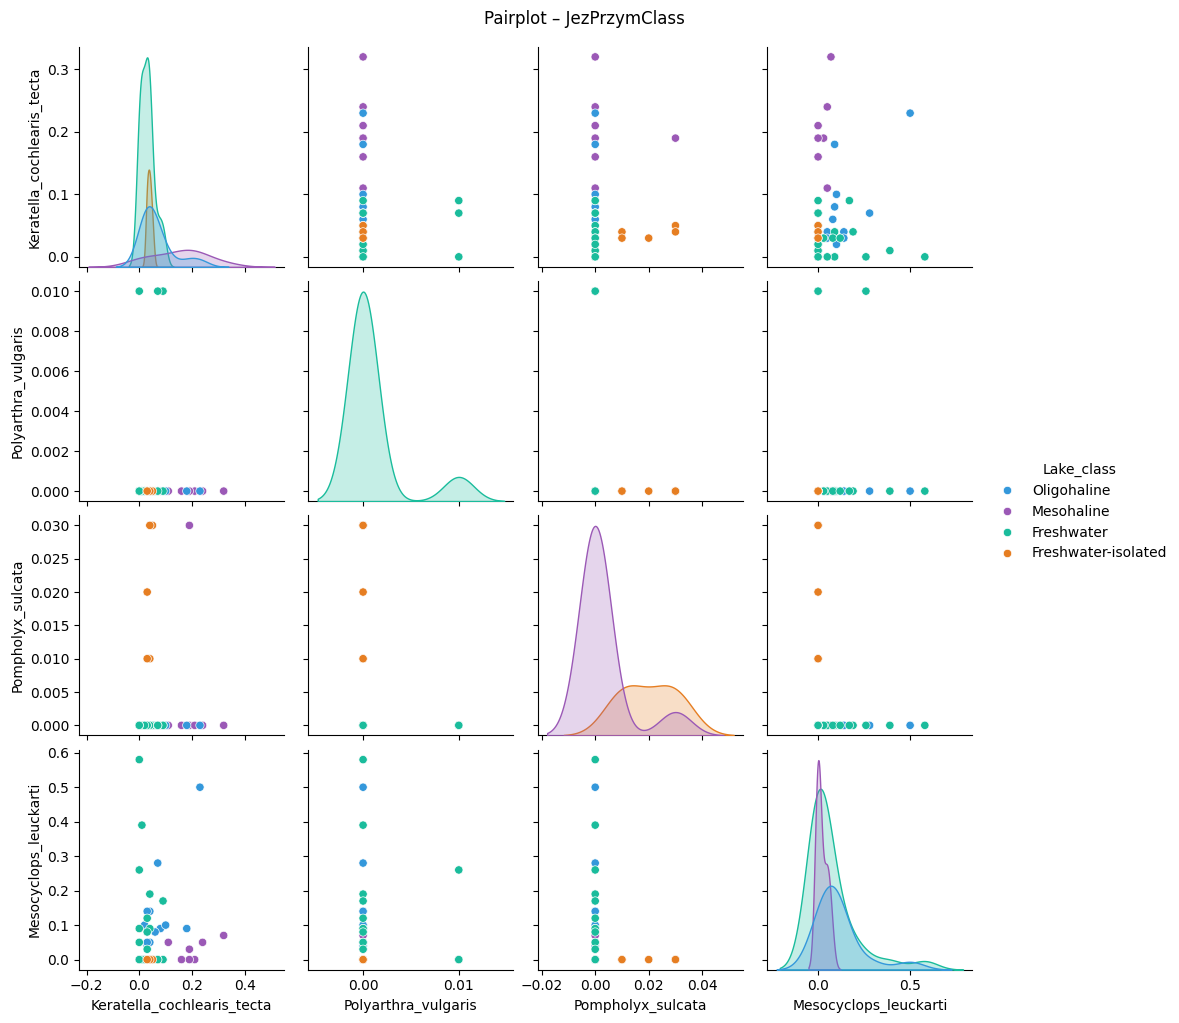

In [14]:
sns.pairplot(df_jez_vis, hue="Lake_class",
             palette={"Oligohaline": "#3498db", "Mesohaline": "#9b59b6",
                      "Freshwater": "#1abc9c", "Freshwater-isolated": "#e67e22"},
             diag_kind="kde")
plt.suptitle("Pairplot – JezPrzymClass", y=1.02)
plt.show()

### 2.2.4 Box Plot

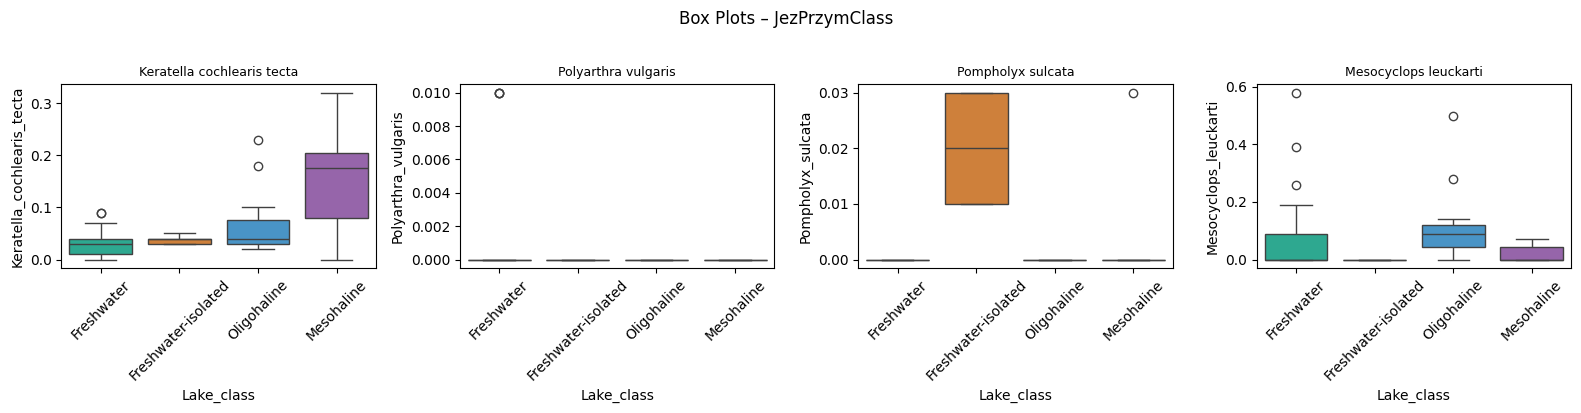

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
class_order = ["Freshwater", "Freshwater-isolated", "Oligohaline", "Mesohaline"]
box_pal = {"Oligohaline": "#3498db", "Mesohaline": "#9b59b6",
           "Freshwater": "#1abc9c", "Freshwater-isolated": "#e67e22"}

for i, col in enumerate(feature_cols_jez):
    sns.boxplot(x="Lake_class", y=col, hue="Lake_class", data=df_jez_vis, ax=axes[i],
                order=class_order, palette=box_pal, legend=False)
    axes[i].set_title(col.replace("_", " "), fontsize=9)
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Box Plots – JezPrzymClass", y=1.02)
plt.tight_layout()
plt.show()

### 2.2.5 Wizualizacja 3D (Keratella, Polyarthra, Mesocyclops)

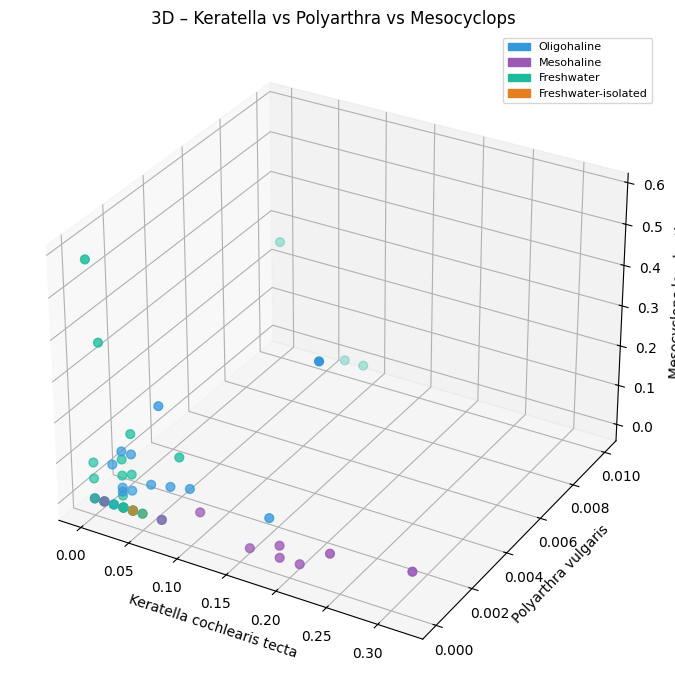

In [16]:
color_map_jez = {"Oligohaline": "#3498db", "Mesohaline": "#9b59b6",
                 "Freshwater": "#1abc9c", "Freshwater-isolated": "#e67e22"}
colors_jez = df_jez["Lake_class"].map(color_map_jez)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_jez["Keratella_cochlearis_tecta"],
           df_jez["Polyarthra_vulgaris"],
           df_jez["Mesocyclops_leuckarti"],
           c=colors_jez, s=40)
ax.set_xlabel("Keratella cochlearis tecta")
ax.set_ylabel("Polyarthra vulgaris")
ax.set_zlabel("Mesocyclops leuckarti")
ax.set_title("3D – Keratella vs Polyarthra vs Mesocyclops")

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map_jez.items()]
ax.legend(handles=legend_handles, fontsize=8)
plt.tight_layout()
plt.show()

## 2.3 Budowa modelu KNN (JezPrzymClass)

In [17]:
X_jez = df_jez[feature_cols_jez]
y_jez = df_jez["Lake_class"]

X_jez_train, X_jez_test, y_jez_train, y_jez_test = train_test_split(
    X_jez, y_jez, test_size=0.2, random_state=0
)

scaler_jez = StandardScaler()
X_jez_train_sc = scaler_jez.fit_transform(X_jez_train)
X_jez_test_sc = scaler_jez.transform(X_jez_test)

knn_jez = KNeighborsClassifier(n_neighbors=5)
knn_jez.fit(X_jez_train_sc, y_jez_train)

y_jez_pred = knn_jez.predict(X_jez_test_sc)

print("Accuracy (JezPrzymClass):", metrics.accuracy_score(y_jez_test, y_jez_pred))
print("\nMacierz pomyłek:")
print(metrics.confusion_matrix(y_jez_test, y_jez_pred))
print("\nRaport klasyfikacji:")
print(metrics.classification_report(y_jez_test, y_jez_pred))

Accuracy (JezPrzymClass): 0.75

Macierz pomyłek:
[[7 0 0]
 [1 1 0]
 [2 0 1]]

Raport klasyfikacji:
              precision    recall  f1-score   support

  Freshwater       0.70      1.00      0.82         7
  Mesohaline       1.00      0.50      0.67         2
 Oligohaline       1.00      0.33      0.50         3

    accuracy                           0.75        12
   macro avg       0.90      0.61      0.66        12
weighted avg       0.82      0.75      0.72        12



### 2.3.1 Wykres błędu klasyfikacji vs liczba sąsiadów K

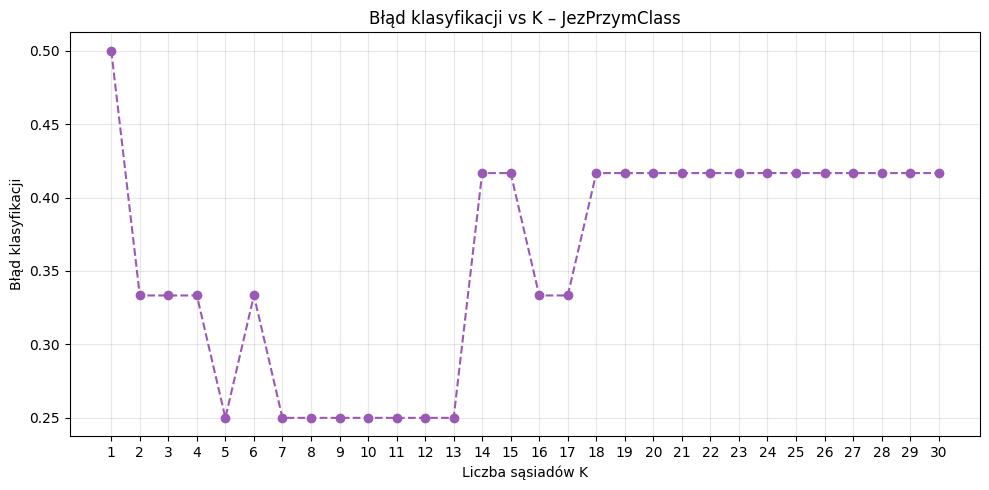

Najlepsze K = 5, błąd = 0.2500


In [18]:
error_rate_jez = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_jez_train_sc, y_jez_train)
    y_temp = knn_temp.predict(X_jez_test_sc)
    error_rate_jez.append(1 - metrics.accuracy_score(y_jez_test, y_temp))

plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rate_jez, marker="o", linestyle="--", color="#9b59b6")
plt.xlabel("Liczba sąsiadów K")
plt.ylabel("Błąd klasyfikacji")
plt.title("Błąd klasyfikacji vs K – JezPrzymClass")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_jez = k_range[np.argmin(error_rate_jez)]
print(f"Najlepsze K = {best_k_jez}, błąd = {min(error_rate_jez):.4f}")

### 2.3.2 Model z optymalnym K (JezPrzymClass)

In [19]:
knn_jez_best = KNeighborsClassifier(n_neighbors=best_k_jez)
knn_jez_best.fit(X_jez_train_sc, y_jez_train)
y_jez_pred_best = knn_jez_best.predict(X_jez_test_sc)

print(f"Accuracy z K={best_k_jez} (JezPrzymClass):", metrics.accuracy_score(y_jez_test, y_jez_pred_best))
print("\nMacierz pomyłek:")
print(metrics.confusion_matrix(y_jez_test, y_jez_pred_best))
print("\nRaport klasyfikacji:")
print(metrics.classification_report(y_jez_test, y_jez_pred_best))

Accuracy z K=5 (JezPrzymClass): 0.75

Macierz pomyłek:
[[7 0 0]
 [1 1 0]
 [2 0 1]]

Raport klasyfikacji:
              precision    recall  f1-score   support

  Freshwater       0.70      1.00      0.82         7
  Mesohaline       1.00      0.50      0.67         2
 Oligohaline       1.00      0.33      0.50         3

    accuracy                           0.75        12
   macro avg       0.90      0.61      0.66        12
weighted avg       0.82      0.75      0.72        12

